# Proyecto Final - Heart disease

### 1. Descripción del problema



**¿Qué problema se resuelve?**

Las enfermedades cardiovasculares son una de las principales causas de muerte a nivel mundial.
Diagnosticarlas a tiempo requiere estudios clínicos costosos e interpretación especializada.
Este proyecto busca predecir, a partir de indicadores clínicos básicos de un paciente, si este
presenta o no enfermedad cardíaca — un problema de **clasificación binaria**.

**¿Por qué es útil?**

Un modelo probabilístico bayesiano no solo predice, sino que **cuantifica la incertidumbre**
de esa predicción. Esto es valioso en medicina, donde saber *qué tan seguro* es el diagnóstico
importa tanto como el diagnóstico mismo.

**Proceso de generación de datos**

El dataset proviene de la **Clínica Cleveland** y fue recopilado originalmente por el
Dr. Robert Detrano. Cada fila representa un paciente que acudió a una evaluación cardíaca.
Las variables fueron medidas mediante exámenes clínicos estándar:

- Electrocardiograma (ECG)
- Análisis de sangre
- Prueba de esfuerzo
- Angiografía coronaria

La variable objetivo (`condition`) indica si el paciente tiene enfermedad cardíaca (`1`) o no (`0`).

**Variables del dataset**

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente (años) |
| `sex` | Sexo (1 = hombre, 0 = mujer) |
| `cp` | Tipo de dolor en el pecho (0 = asintomático, 1 = atípico, 2 = no anginoso, 3 = típico) |
| `trestbps` | Presión arterial en reposo (mmHg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en sangre > 120 mg/dl (1 = sí, 0 = no) |
| `restecg` | Resultado del electrocardiograma en reposo (0, 1, 2) |
| `thalach` | Frecuencia cardíaca máxima alcanzada (bpm) |
| `exang` | Angina inducida por ejercicio (1 = sí, 0 = no) |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST en ejercicio (0 = descendente, 1 = plana, 2 = ascendente) |
| `ca` | Número de vasos principales coloreados por fluoroscopía (0–3) |
| `thal` | Tipo de defecto cardíaco (0 = normal, 1 = defecto fijo, 2 = defecto reversible) |
| `condition` | **Variable objetivo**: 0 = sin enfermedad, 1 = con enfermedad |

### 2. Análisis exploratorio de datos (EDA)

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importamos nuestros datos 

In [36]:
heart_data = pd.read_csv('heart_cleveland_upload.csv')
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Veamos que tal con nuestra variable de salida `condition`

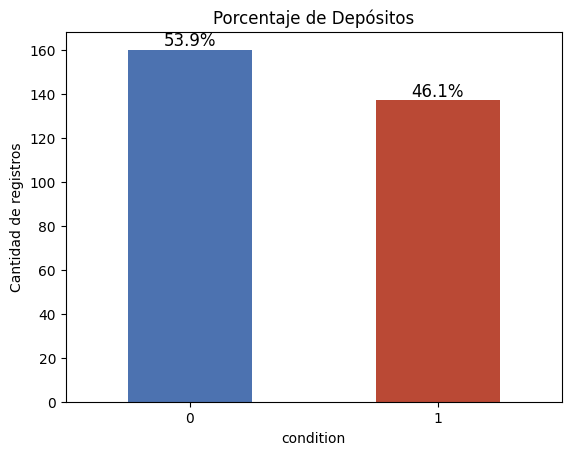

In [37]:
counts = heart_data['condition'].value_counts()
percentages = heart_data['condition'].value_counts(normalize=True) * 100

ax = counts.plot(kind='bar', color=['#4C72B0', "#BA4935"])

for i, p in enumerate(percentages):
    ax.annotate(f'{p:.1f}%', 
                (i, counts[i]), 
                ha='center', 
                va='bottom', 
                fontsize=12)

plt.title('Porcentaje de Depósitos')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=0)
plt.show();

Esta balanceada, veamos que tipo de variables tenemos y si hay nulos.

In [38]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


**VARIABLES NUEMERICAS**

In [39]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
heart_data[numeric_cols].describe()

,age,trestbps,chol,thalach,oldpeak
count,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556
std,9.049736,17.762806,51.997583,22.941562,1.166123
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000
75%,61.000000,140.000000,276.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


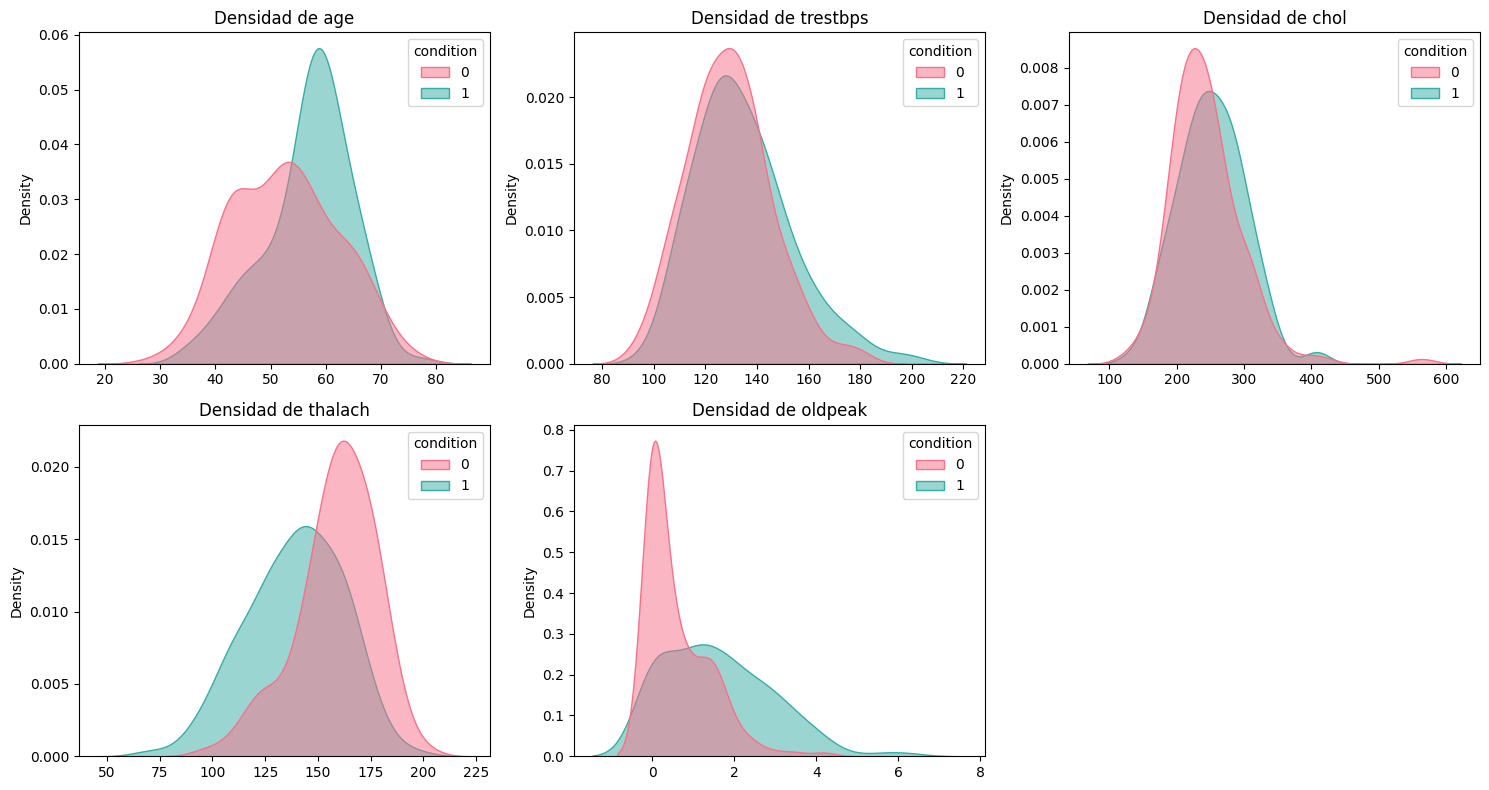

In [40]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(data=heart_data, x=col, hue='condition', fill=True, common_norm=False, palette='husl', alpha=0.5)
    plt.title(f'Densidad de {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

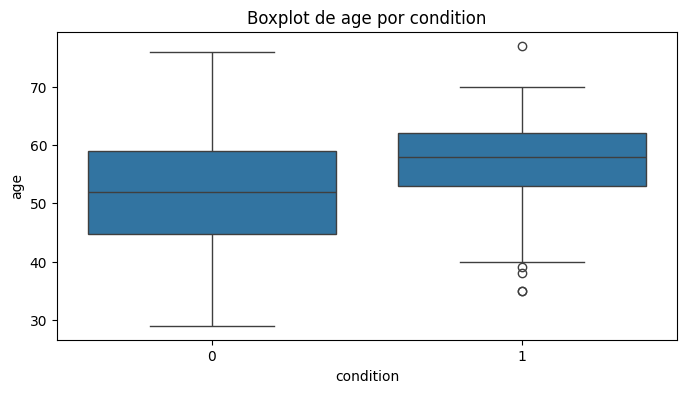

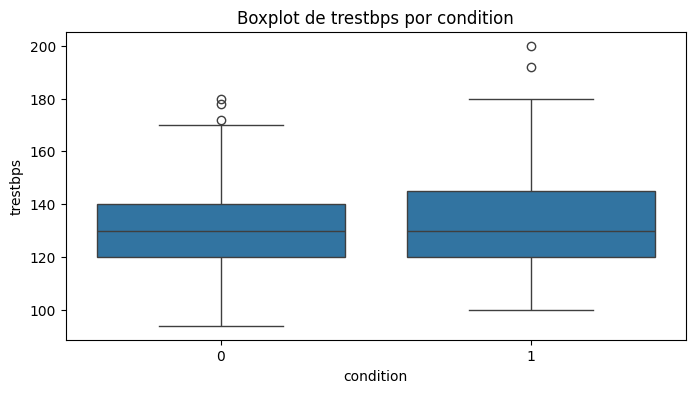

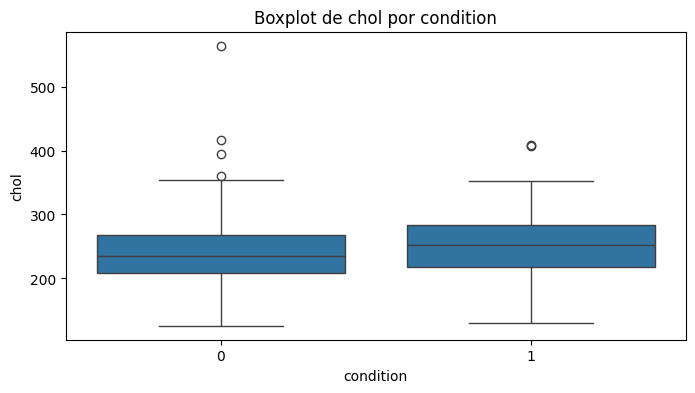

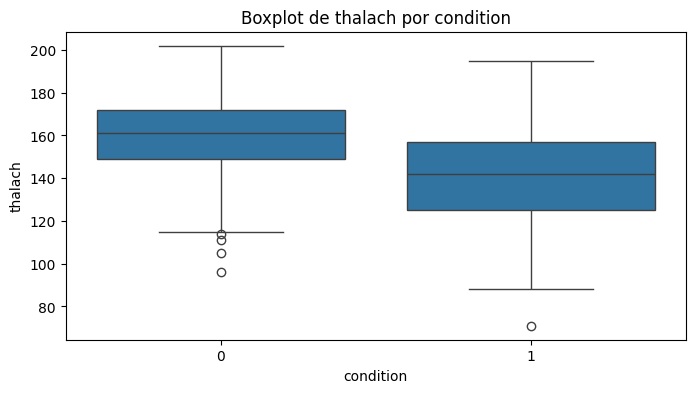

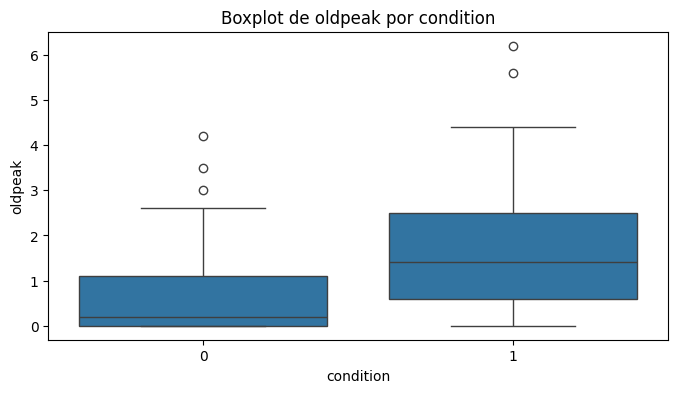

In [41]:
for column in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='condition', y=column, data=heart_data)
    plt.title(f'Boxplot de {column} por condition')
    plt.show()

**VARIABLES CATEGORICAS**

In [42]:
cat_cols = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal', 'fbs']
heart_data[cat_cols].astype('object').describe()

,sex,cp,restecg,exang,slope,ca,thal,fbs
count,297,297,297,297,297,297,297,297
unique,2,4,3,2,3,4,3,2
top,1,3,0,0,0,0,0,0
freq,201,142,147,200,139,174,164,254


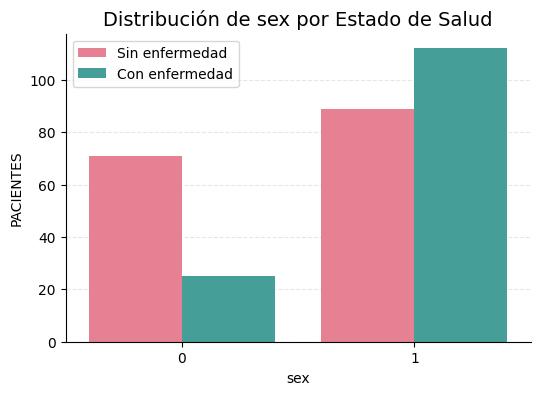

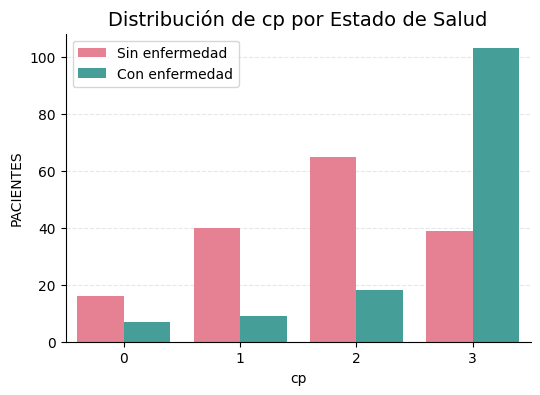

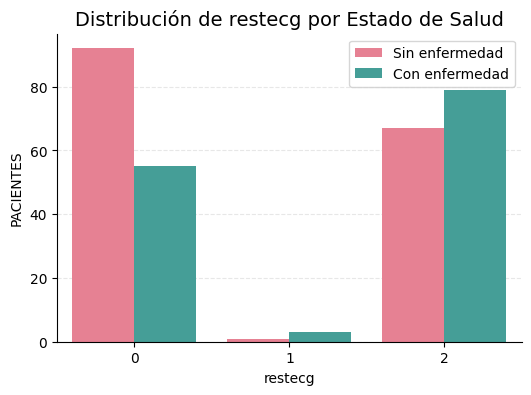

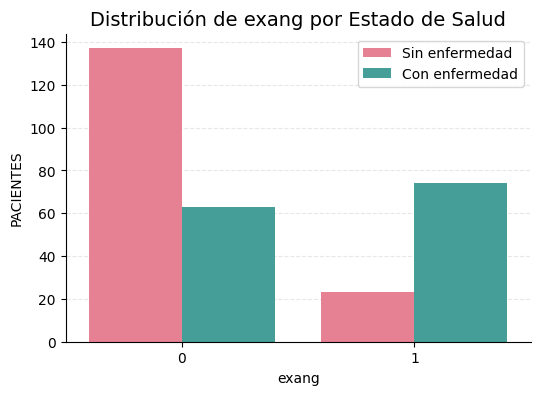

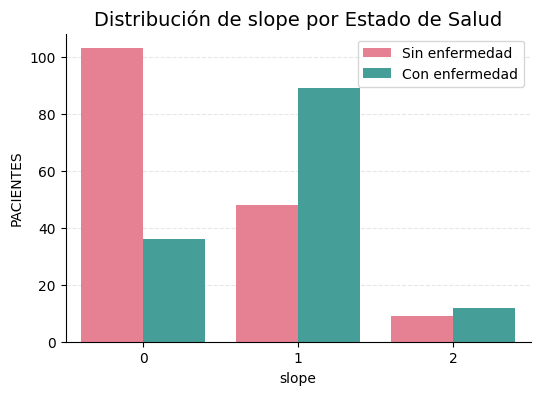

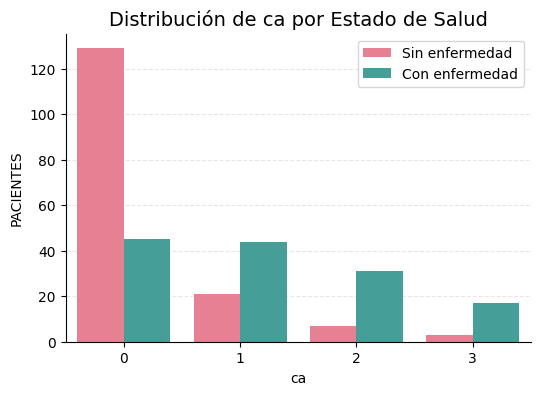

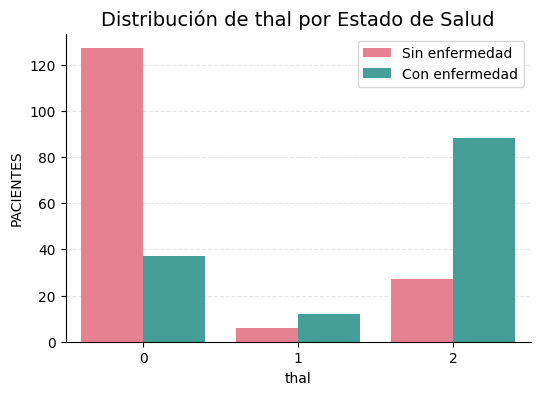

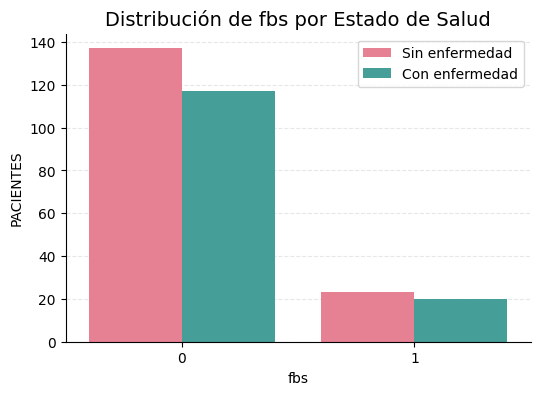

In [43]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    
    ax = sns.countplot(data=heart_data, x=col, hue='condition', palette='husl')
    plt.title(f'Distribución de {col} por Estado de Salud', fontsize=14)
    plt.legend(labels=['Sin enfermedad', 'Con enfermedad'])
    plt.ylabel('PACIENTES')
    plt.xlabel(col)
    
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    sns.despine()
    plt.show()

#### Conclusiones del EDA

El dataset tiene 297 pacientes sin valores nulos y un balance de clases adecuado el cual es de 53.9% sin enfermedad y 46.1% con enfermedad que lo que nos permite es poder entrenar el modelo sin técnicas de remuestreo.

De las variables numéricas analizadas, thalach y oldpeak son las que mejor separan los grupos ya que nos hablan de que los pacientes con enfermedad alcanzan una frecuencia cardíaca máxima menor 139 bpm contra 158 bpm y presentan mayor depresión del segmento ST 1.59 contra 0.60. 

En cambio, chol y trestbps muestran distribuciones muy similares entre grupos eso quiere decir que muy seguro no nos van a ayudar mucho en el futuro. 

De las variables categóricas, thal, ca y cp son las más informativas. 
El defecto reversible (thal=2) y tener vasos coronarios obstruidos (ca > 0) se asocian claramente con mayor prevalencia de enfermedad. El colesterol y la glucosa en sangre (fbs) prácticamente no discriminan entre clases.


### 3. Estructura de modelo para resolver el problema

Se va a utilizar un Regresor logístico Bayesiano

¿Por qué Regresión Logística Bayesiana?
 
La variable objetivo `condition` es **binaria** (0 = sin enfermedad, 1 = con enfermedad),
lo que descarta modelos de regresión lineal directa. Entonces regresión logística bayesiana es
la elección natural.
 
Modela directamente la **probabilidad** de que un paciente tenga enfermedad cardíaca.

Al ser bayesiana, no entrega un solo número sino una **distribución de probabilidad**
sobre cada parámetro — lo que permite cuantificar la incertidumbre del modelo.


### 4. Definición del modelo


#### 1 Entradas y salidas

Entradas (variables predictoras)

| Variable | Tipo | Preprocesamiento |
|---|---|---|
| `age` | Numérica continua | Estandarización (z-score) |
| `sex` | Binaria (0/1) | Sin cambio |
| `exang` | Binaria (0/1) | Sin cambio |
| `oldpeak` | Numérica continua | Estandarización (z-score) |
| `thalach` | Numérica continua | Estandarización (z-score) |
| `cp` | Categórica (0–3) | One-hot encoding → `cp_1`, `cp_2`, `cp_3` |
| `thal` | Categórica (0–2) | One-hot encoding → `thal_1`, `thal_2` |
| `ca` | Categórica (0–3) | One-hot encoding → `ca_1`, `ca_2`, `ca_3` |

Las variables continuas se estandarizan

Salida

| Variable | Tipo | Descripción |
|---|---|---|
| `condition` | Binaria (0/1) | Probabilidad de que el paciente tenga enfermedad cardíaca |



#### 2 Limitaciones del modelo

**Lo que el modelo SÍ modela:**
- La relación entre indicadores clínicos básicos y la presencia de enfermedad cardíaca.
- La incertidumbre en los parámetros $\beta$ mediante distribuciones posteriores.


**Lo que el modelo NO modela:**
- **Interacciones entre variables** — por ejemplo, si el efecto de la edad es
  distinto en hombres y mujeres.
- **Efectos no lineales** — relaciones en forma de U o umbrales entre predictores
  y la variable respuesta.
- **Evolución temporal** — el modelo trata cada paciente como una observación
  independiente; no captura cambios en el tiempo.
- **Causalidad** — el modelo es predictivo, no causal. Un coeficiente alto no
  implica que la variable *cause* la enfermedad.
- **Variables no disponibles** — factores como historial familiar, hábitos de
  tabaquismo o sedentarismo no están en el dataset y no se modelan.


#### 3 Supuestos del modelo

Supuestos explícitos

1. **Likelihood Bernoulli** — cada observación $y_i$ es una realización independiente
   de una distribución Bernoulli con probabilidad $p_i$.

2. **Función de enlace logit** — la relación entre los predictores y la probabilidad
   es lineal en escala log-odds.

3. **Priors normales estándar** — se asume que antes de ver los datos, los coeficientes
   son igualmente probables alrededor de cero con desviación estándar 1. Esto es un
   prior débilmente informativo que regulariza el modelo sin imponer creencias fuertes.

Supuestos implícitos

1. **Independencia condicional** — dado el vector de predictores $x_i$, las observaciones
   son independientes entre sí. No se modela correlación entre pacientes.

2. **Aditividad** — el efecto de cada predictor sobre el log-odds es aditivo e
   independiente del valor de los demás predictores.

3. **Estacionariedad** — se asume que la relación entre predictores y enfermedad
   es estable; el modelo no cambia en el tiempo.

4. **Representatividad** — se asume que los 297 pacientes de la Clínica Cleveland
   son representativos de la población de interés, lo cual puede no ser cierto para
   otras poblaciones o regiones.



#### 4 Definición del modelo en lenguaje probabilístico

$$
\begin{align}
\begin{array}{lcl}
condition_i & \sim & \text{Bernoulli}(p_i) \\[6pt]
\text{logit}(p_i) & = & \alpha \\
& + & \beta_{cp1}\,cp1_i + \beta_{cp2}\,cp2_i + \beta_{cp3}\,cp3_i \\
& + & \beta_{thal1}\,thal1_i + \beta_{thal2}\,thal2_i \\
& + & \beta_{ca1}\,ca1_i + \beta_{ca2}\,ca2_i + \beta_{ca3}\,ca3_i \\
& + & \beta_{oldpeak}\,oldpeak_i + \beta_{thalach}\,thalach_i \\
& + & \beta_{exang}\,exang_i + \beta_{age}\,age_i + \beta_{sex}\,sex_i \\[6pt]
\alpha & \sim & \text{Normal}(0, 1) \\
\beta_k & \sim & \text{Normal}(0, 1) \qquad \text{for all } k \\
\end{array}
\end{align}
$$



#### Validación de previas (Simulación Predictiva Previa)

Antes de correr el modelo, verificamos que los priors `Normal(0, 1)` 
tengan sentido clínico simulando distribuciones de probabilidad previas.

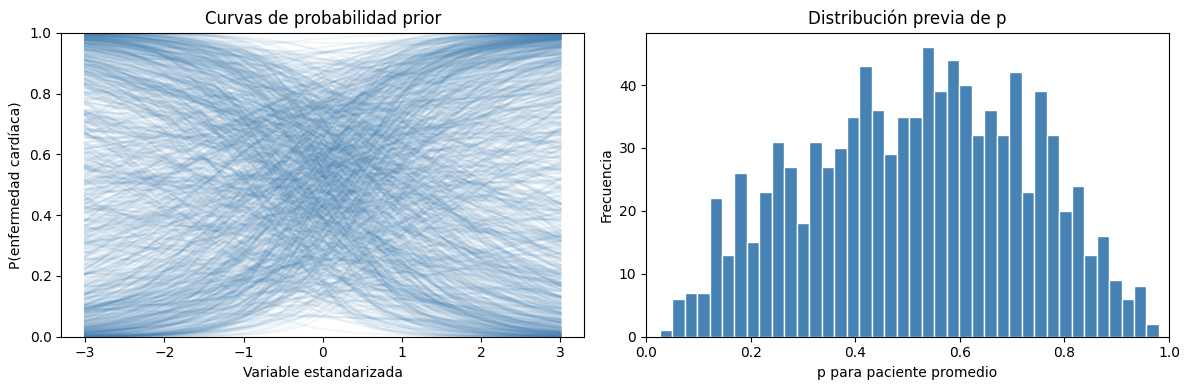

Media de p prior: 0.515


In [44]:
from scipy.special import expit as logistic
import numpy as np

n_samples = 1000

alpha_s = np.random.normal(0, 1, n_samples)
beta_s  = np.random.normal(0, 1, n_samples)

z_range = np.linspace(-3, 3, 100)

p_samples = logistic(alpha_s[:, None] + beta_s[:, None] * z_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z_range, p_samples.T, 'steelblue', alpha=0.07)
axes[0].set_xlabel('Variable estandarizada')
axes[0].set_ylabel('P(enfermedad cardíaca)')
axes[0].set_title('Curvas de probabilidad prior')
axes[0].set_ylim(0, 1)

p_promedio = logistic(alpha_s)
axes[1].hist(p_promedio, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('p para paciente promedio')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución previa de p')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f'Media de p prior: {p_promedio.mean():.3f}')

#### Conclusiones de los priors: 
- Las curvas de probabilidad cubren todo el rango de 0 a 1 
  con pendientes positivas y negativas, esto nos quiere decir que el modelo no asume de antemano 
  si el paciente tiene o no enfermedad cardíaca.
- La distribución previa de p no es perfectamente uniforme pero 
  su media es de 0.509, prácticamente 0.5, lo que nos confirma que el prior 
  no favorece ninguna clase sobre la otra.
- Dado que el dataset está balanceado 46% contra 54%, estos priors son 
  suficientemente débiles para dejar que los datos dominen la inferencia, pero esto quiere decir que nuestros prios son debilmente informativos, ahora seguímos con el modelo: 

### 5. Implementación del modelo en PyMC

In [45]:
import pymc as pm
import arviz as az
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Dividamos primero en nuestros datos de prueba y entrenamiento

In [46]:
df_model = pd.get_dummies(heart_data, columns=['cp', 'thal', 'ca'], drop_first=True, dtype=int)
df_model

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,condition,cp_1,cp_2,cp_3,thal_1,thal_2,ca_1,ca_2,ca_3
0,69,1,160,234,1,2,131,0,0.1,1,0,0,0,0,0,0,1,0,0
1,69,0,140,239,0,0,151,0,1.8,0,0,0,0,0,0,0,0,1,0
2,66,0,150,226,0,0,114,0,2.6,2,0,0,0,0,0,0,0,0,0
3,65,1,138,282,1,2,174,0,1.4,1,1,0,0,0,0,0,1,0,0
4,64,1,110,211,0,2,144,1,1.8,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,152,223,0,0,181,0,0.0,0,1,0,0,1,0,1,0,0,0
293,39,1,118,219,0,0,140,0,1.2,1,1,0,0,1,0,1,0,0,0
294,35,1,120,198,0,0,130,1,1.6,1,1,0,0,1,0,1,0,0,0
295,35,0,138,183,0,0,182,0,1.4,0,0,0,0,1,0,0,0,0,0


In [47]:
X = df_model.drop(columns='condition')
y = df_model['condition']

feature_cols = ['cp_1', 'cp_2', 'cp_3', 'thal_1', 'thal_2', 'ca_1', 'ca_2', 'ca_3', 'oldpeak', 'thalach', 'exang', 'age', 'sex']

X_train, X_test, y_train, y_test = train_test_split(
    X[feature_cols], y, test_size=0.2, random_state=42
)

Ahora vamos hacer las transformaciones necesarias a nuestras variables

In [48]:
scaler = StandardScaler()

continuous = ['age', 'oldpeak', 'thalach']

X_train_scaled = X_train.copy()
X_train_scaled[continuous] = scaler.fit_transform(X_train_scaled[continuous])

Creamos nuestro modelo

In [49]:
with pm.Model() as heart_model:
 
    
    X_data = pm.Data('X_data', X_train_scaled)
    y_data = pm.Data('y_data', y_train)


   
    alpha = pm.Normal('alpha', mu=0, sigma=1)
    beta_cp_1 = pm.Normal("beta_cp_1", mu=0, sigma=1)
    beta_cp_2 = pm.Normal("beta_cp_2", mu=0, sigma=1)
    beta_cp_3 = pm.Normal("beta_cp_3", mu=0, sigma=1)
 
    beta_thal_1 = pm.Normal("beta_thal_1", mu=0, sigma=1)
    beta_thal_2 = pm.Normal("beta_thal_2", mu=0, sigma=1)

    beta_ca_1 = pm.Normal("beta_ca_1", mu=0, sigma=1)
    beta_ca_2 = pm.Normal("beta_ca_2", mu=0, sigma=1)
    beta_ca_3 = pm.Normal("beta_ca_3", mu=0, sigma=1)

    beta_oldpeak = pm.Normal("beta_oldpeak", mu=0, sigma=1)
    beta_thalach = pm.Normal("beta_thalach", mu=0, sigma=1)
    beta_exang = pm.Normal("beta_exang", mu=0, sigma=1)
    beta_age = pm.Normal("beta_age", mu=0, sigma=1)
    beta_sex = pm.Normal("beta_sex", mu=0, sigma=1)


    # --- Predictor lineal ---

    logit_p = (
        alpha
        + beta_cp_1 * X_data[:, 0] 
        + beta_cp_2 * X_data[:, 1] 
        + beta_cp_3 * X_data[:, 2] 
        + beta_thal_1 * X_data[:, 3] 
        + beta_thal_2 * X_data[:, 4] 
        + beta_ca_1 * X_data[:, 5] 
        + beta_ca_2 * X_data[:, 6] 
        + beta_ca_3 * X_data[:, 7] 
        + beta_oldpeak * X_data[:, 8] 
        + beta_thalach * X_data[:, 9]
        + beta_exang * X_data[:, 10] 
        + beta_age * X_data[:, 11] 
        + beta_sex * X_data[:, 12] 
    )

 
    # --- Función link (sigmoide) ---
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p))

    deposit_obs = pm.Bernoulli('condition_obs', p=p, observed=y_data)

### 6. Interpretación y Evaluación del modelo

In [ ]:
# Muestreo de la distribución posterior
with heart_model:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_cp_1, beta_cp_2, beta_cp_3, beta_thal_1, beta_thal_2, beta_ca_1, beta_ca_2, beta_ca_3, beta_oldpeak, beta_thalach, beta_exang, beta_age, beta_sex]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 25 seconds.


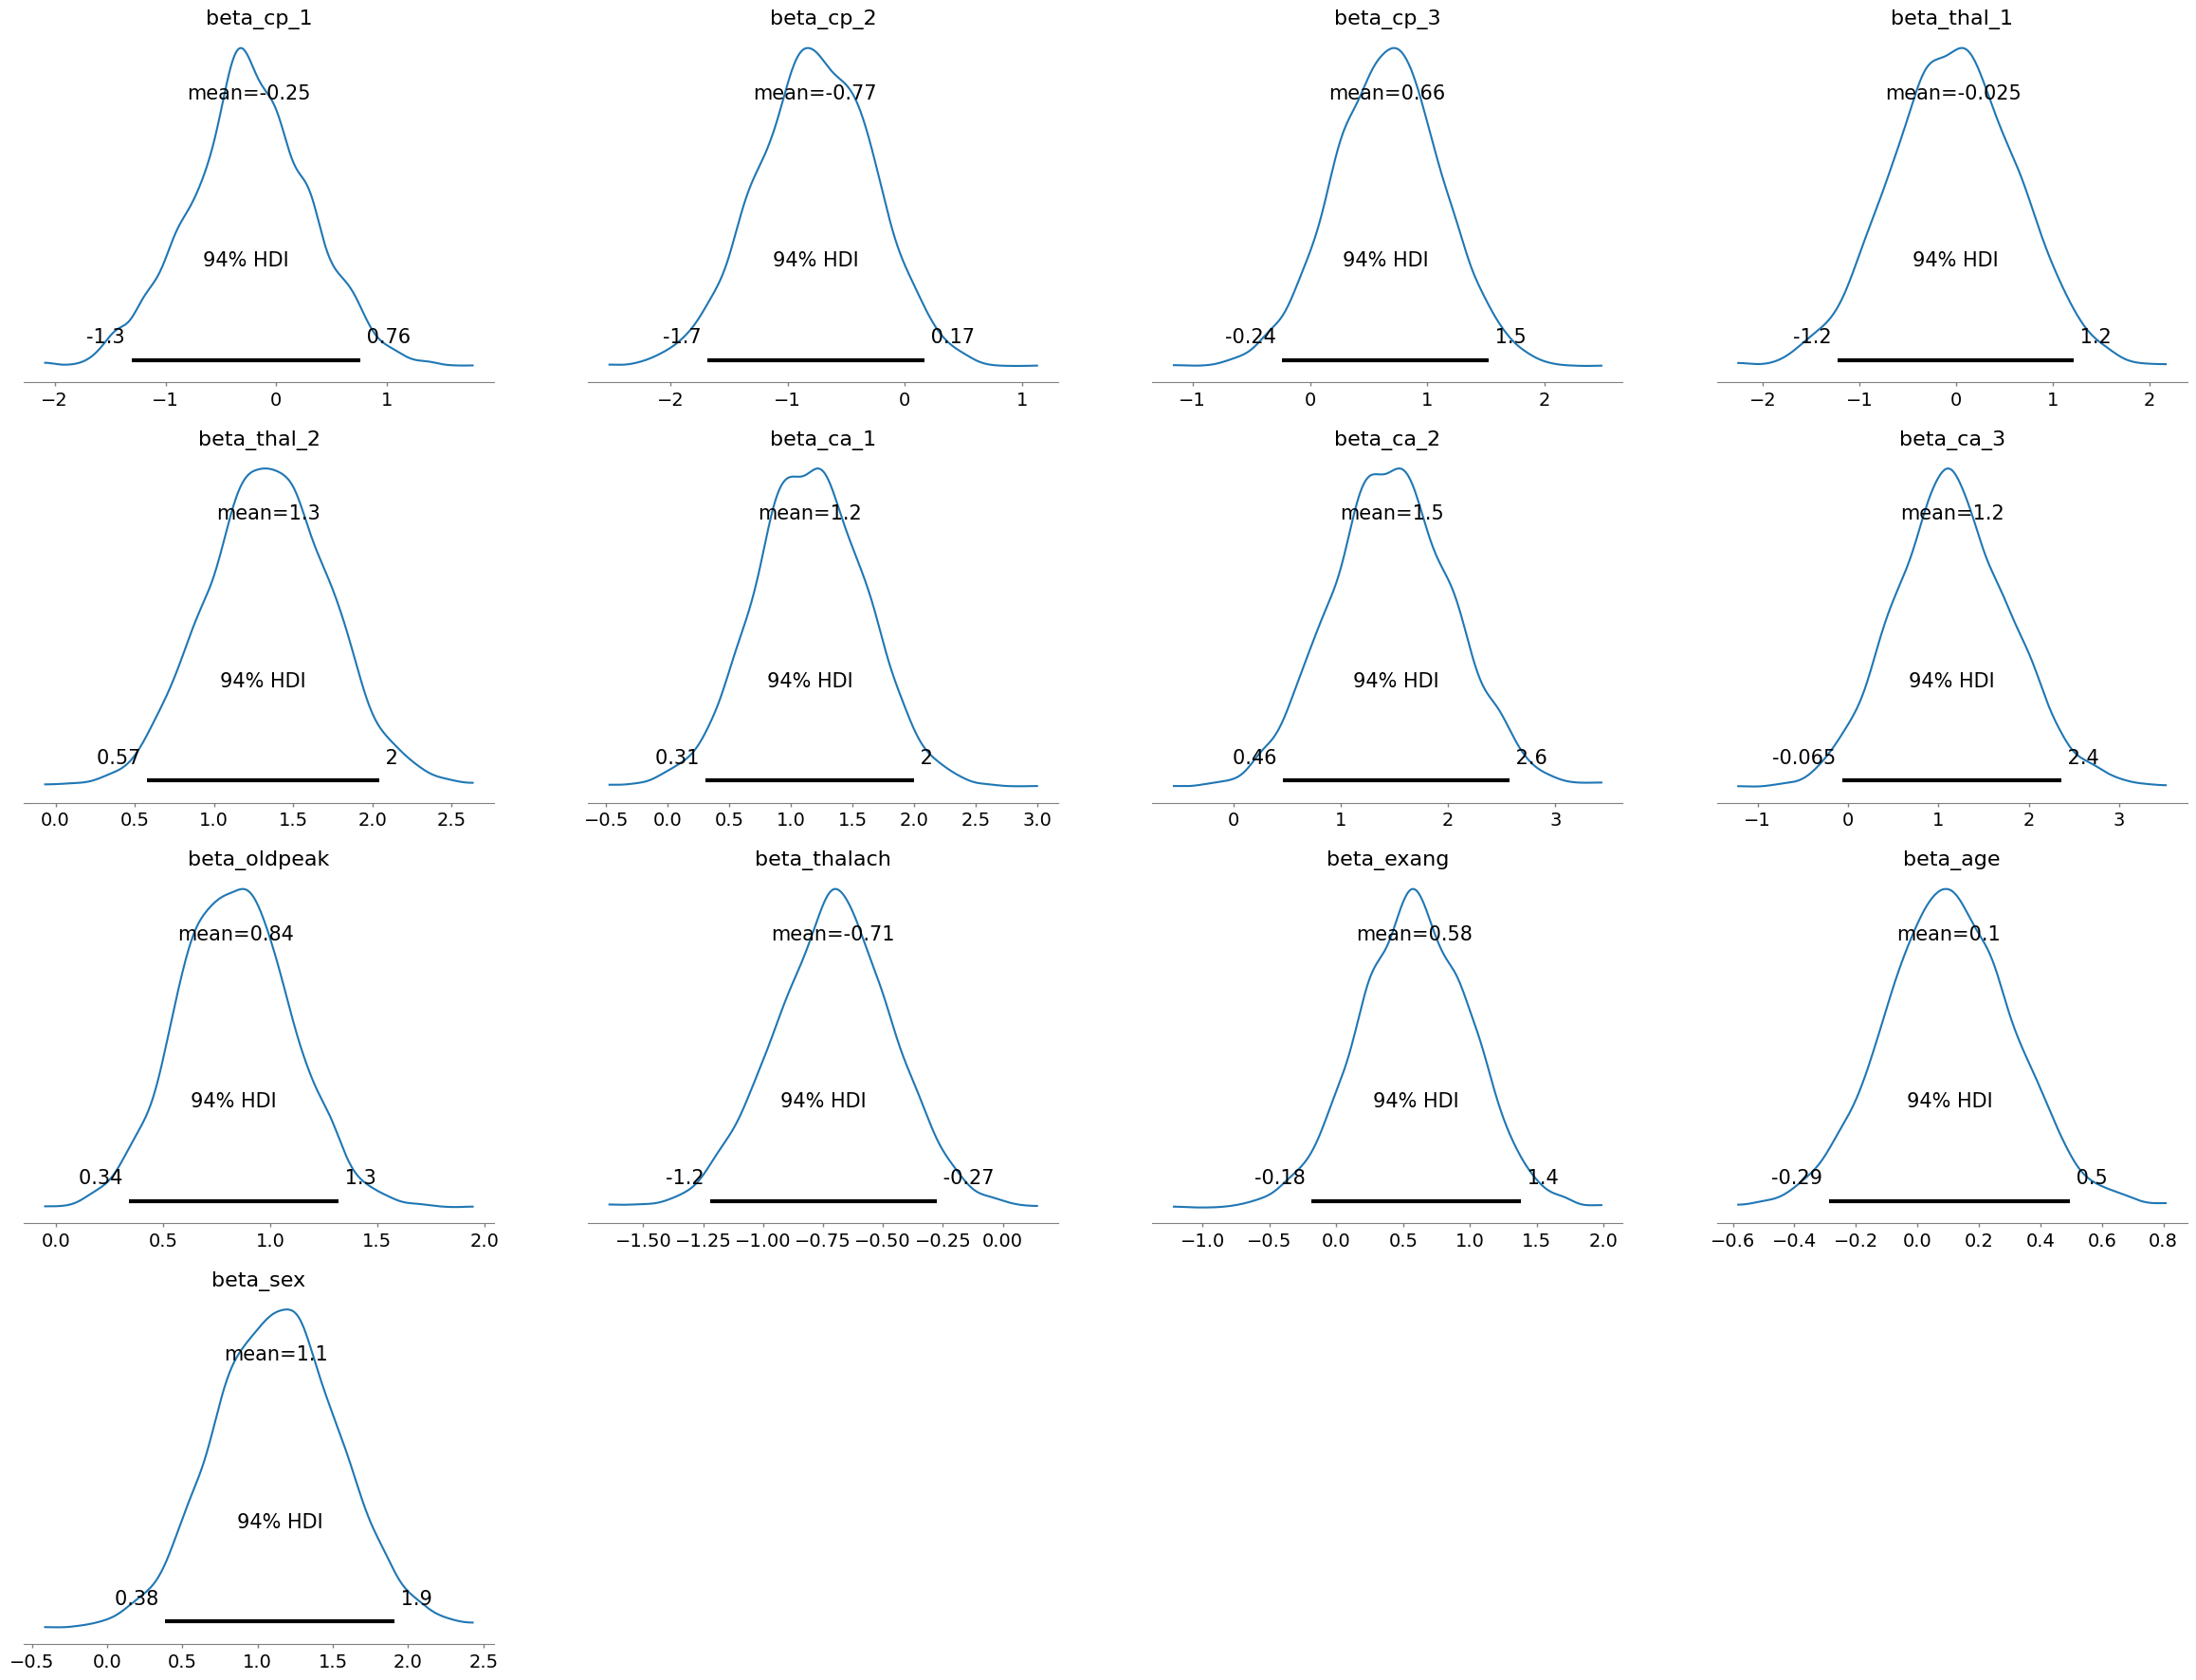

In [ ]:
az.plot_posterior(idata, var_names=[f'beta_{name}' for name in feature_cols]);

### Conclusiones e interpretación de las distribuciones posteriores

**beta_thal_2** → mean=1.3, HDI: [0.57, 2]  
El defecto cardíaco reversible (thal=2) es el predictor más claro del modelo. 
A diferencia de un defecto fijo, el reversible indica que ciertas zonas del corazón 
no reciben suficiente sangre durante el esfuerzo pero sí en reposo lo que es una señal directa 
de isquemia activa. El HDI completamente positivo confirma que estos pacientes 
tienen significativamente mayor probabilidad de enfermedad cardíaca.

**beta_ca_1** → mean=1.1, HDI: [0.31, 2]  
**beta_ca_2** → mean=1.5, HDI: [0.46, 2.6]  
El número de vasos coronarios principales con obstrucción visible (coloreados por 
fluoroscopía) es un predictor sólido. Tener 1 o 2 vasos obstruidos aumenta 
significativamente el riesgo y el efecto crece con el número de vasos, lo que 
tiene sentido clínico: a mayor obstrucción coronaria, menos sangre llega al músculo 
cardíaco y mayor es la probabilidad de enfermedad.

**beta_oldpeak** → mean=0.84, HDI: [0.34, 1.3]  
La depresión del segmento ST mide cuánto cae la señal eléctrica del corazón durante 
el ejercicio respecto al reposo. Valores altos indican que el corazón sufre bajo 
esfuerzo esto es un indicador directo de isquemia miocárdica. El HDI completamente 
positivo confirma que a mayor oldpeak (cambio notorio en el electrocardiograma), mayor probabilidad de enfermedad.

**beta_thalach** → mean=-0.70, HDI: [-1.2, -0.27]  
Es el único predictor continuo con efecto negativo claro. La frecuencia cardíaca 
máxima alcanzada durante el ejercicio refleja la capacidad del corazón de responder 
al esfuerzo osea que un corazón sano puede acelerar más. A mayor frecuencia máxima 
alcanzada, menor probabilidad de enfermedad cardíaca. El HDI completamente negativo 
lo confirma como predictor importante.

**beta_sex** → mean=1.1, HDI: [0.38, 1.9]  
Ser hombre (sex=1) se asocia con mayor probabilidad de enfermedad cardíaca respecto 
a ser mujer. Esto es consistente con la epidemiología cardiovascular que dice que los hombres 
desarrollan enfermedad coronaria en promedio 10 años antes que las mujeres, 
principalmente por diferencias hormonales y factores de riesgo metabólico.


**beta_cp_1** (dolor en el pecho atípico), **beta_cp_2** (dolor no anginoso) y 
**beta_cp_3** (dolor típico anginoso), **beta_thal_1** (defecto cardíaco fijo, 
sin cambio con el flujo sanguíneo), **beta_ca_3** (3 vasos coronarios principales 
con obstrucción visible), **beta_exang** (angina provocada por actividad física) 
y **beta_age** (edad del paciente) presentan HDIs que cruzan o rozan el cero, 
por lo que **no aportan evidencia suficiente** de un efecto claro sobre el 
diagnóstico una vez controladas las demás variables.

In [ ]:
X_test_scaled = X_test.copy()
X_test_scaled[continuous] = scaler.transform(X_test_scaled[continuous])

with heart_model:
    pm.set_data({'X_data': X_test_scaled, 'y_data': y_test})
    ppc = pm.sample_posterior_predictive(idata, random_seed=42)

Sampling: [condition_obs]


Output()

In [ ]:
# Construimos la curva precision-recall
from sklearn.metrics import precision_recall_curve, f1_score
y_scores = ppc.posterior_predictive["condition_obs"].mean(dim=["chain", "draw"])
precision, recall, thresholds = precision_recall_curve(y_true=y_test, y_score=y_scores)
pr_curve = pd.DataFrame({'Precision': precision, 'Recall': recall})
# Construimos la curva F1 vs. umbrales
f1 = pd.Series({t: f1_score(y_true=y_test, y_pred=y_scores > t) for t in thresholds})
# Encontramos el umbral que maximiza F1
best_threshold = f1.idxmax()
print(best_threshold)
pr_curve.loc[np.where(thresholds == best_threshold)]

0.2355


,Precision,Recall
20,0.65,0.928571


In [ ]:
# Evaluamos el modelo con el mejor umbral
y_pred_best = (y_scores > best_threshold).astype(int)
accuracy_best = (y_test == y_pred_best).mean()
print(f'Mejor umbral:  {best_threshold:.3f}')
print(f'Mejor F1:      {f1.max():.3f}')
print(f'Accuracy:      {accuracy_best:.3f}')

Mejor umbral:  0.235
Mejor F1:      0.776
Accuracy:      0.750


### Evaluación del modelo

Se evaluó el modelo sobre el conjunto de prueba de 60 observaciones lo que es 20% del dataset

El umbral óptimo se obtuvo maximizando el F1 Score en lugar de solo usar 0.5 por 
defecto, buscamos el umbral que mejor balancea precisión y recall. 

Pasando esto a un contexto médico esto es importante ya que decidimos que era preferente clasificar de más pacientes 
como enfermos (algunos falsos positivos) antes que dejar pasar un caso real 
sin detectar (falso negativo)

Con el umbral óptimo de **0.235** los resultados son:

| Métrica | Valor |
|---|---|
| Umbral óptimo | 0.235 |
| Mejor F1 | 0.776 |
| Accuracy | 75.0% |
| Precision | 0.650 |
| Recall | 0.929 |

El **recall de 0.929** es el resultado más relevante ya que el modelo detecta el 
92.9% de los pacientes con enfermedad cardíaca real, lo que lo hace útil como 
herramienta de screening inicial. El costo de ese alto recall es una precision 
de 0.65, es decir, algunos pacientes sanos son clasificados como enfermos y 
requerirían estudios adicionales para confirmación.

El umbral bajo (0.235) refleja exactamente esa prioridad: ante la duda, el 
modelo prefiere sospechar enfermedad. Esto es consistente con el objetivo 
clínico del modelo el cual NO BUSCA reemplazar al médico, sino identificar casos de riesgo 
que merezcan atención prioritaria.